# NALAPRO Final Project Tasks 3 and 4 - Naa Lamiorkor Boye

This notebook continues after the Task 1 neural-network experiments and Task 2 BERT classification fine-tuning.

Goals:
- **Task 3:** Continue BERT training with masked language modeling on the 20 Newsgroups training text, then fine-tune that adapted BERT model for classification.
- **Task 4:** Run **Llama-3** zero-shot and few-shot classification experiments and evaluate them.

Experiment tracking:
- W&B project: `nalapro-project`
- Each major experiment creates a separate W&B run.
- Save final CSV files and plots in the repository, but do **not** upload the raw dataset.

## Project Tracking, Tools, and References

### Code Repository
GitHub repository: https://github.com/Lamiorkor/NALAPRO_Final_Project

### Experiment Tracking
This project was developed in Google Colab because GPU access was needed for BERT fine-tuning.

Experiment tracking:
- W&B link: https://wandb.ai/naalamiorkor-boye-hochschule-luzern/nalapro-project

### Tools Used
- Google Colab with GPU runtime
- Python
- NumPy, Pandas
- Matplotlib, Seaborn
- Scikit-learn
- NLTK
- Gensim Word2Vec
- PyTorch
- Hugging Face Transformers
- Hugging Face Datasets / Evaluate
- Llama-3
- ChatGPT / AI assistance for debugging, explanation, and structuring code

### AI Use Statement
AI assistance was used to help debug errors, explain concepts, improve code structure, and support interpretation of results. All code was reviewed, adapted, and understood before inclusion.

### Code Sources
Most code was written and adapted by me for this project through vibe coding with ChatGPT. External libraries were used through their official APIs.

## Installing Libraries

In [ ]:
!pip install --upgrade pip -q

!pip install -q --default-timeout=180 --retries=10 \
    transformers datasets accelerate evaluate wandb \
    scikit-learn pandas numpy matplotlib seaborn \
    sentencepiece protobuf huggingface_hub

In [ ]:
!pip install -U --no-cache-dir --default-timeout=180 --retries=10 bitsandbytes>=0.46.1

## Login, Configuration, and Reproducibility


In [ ]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import wandb
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from huggingface_hub import login as hf_login
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForCausalLM,
    AutoModelForMaskedLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    pipeline,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

WANDB_PROJECT = "nalapro-project"
os.environ["WANDB_PROJECT"] = WANDB_PROJECT
os.environ["WANDB_LOG_MODEL"] = "false"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

MAX_MLM_TRAIN_SAMPLES = None
MAX_CLS_TRAIN_SAMPLES = None
MAX_TEST_SAMPLES_FOR_LLAMA = 2000
MAX_TEST_SAMPLES_FOR_BERT_EVAL = None

BERT_MODEL_NAME = "bert-base-uncased"
LLAMA_MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"
OUTPUT_DIR = Path("task_3_4_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
import bitsandbytes as bnb
import torch

print("bitsandbytes:", bnb.__version__)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))

bitsandbytes: 0.49.2
cuda available: True
gpu: NVIDIA A100-SXM4-80GB


In [ ]:
try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
    wandb_key = userdata.get("WANDB_API_KEY")
except Exception:
    hf_token = os.environ.get("HF_TOKEN")
    wandb_key = os.environ.get("WANDB_API_KEY")

if hf_token:
    hf_login(token=hf_token)
else:
    print("No HF_TOKEN found. If you use Llama-3, run huggingface_hub.login() or set HF_TOKEN.")

if wandb_key:
    wandb.login(key=wandb_key)
else:
    wandb.login()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


# Shared Dataset Preparation

This matches the Task 2 setup: remove headers, footers, and quotes; remove empty documents; then create train/validation/test splits.

In [ ]:
train_data = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
test_data = fetch_20newsgroups(subset="test", remove=("headers", "footers", "quotes"))

label_names = train_data.target_names
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in id2label.items()}

train_df = pd.DataFrame({"text": train_data.data, "label": train_data.target})
test_df = pd.DataFrame({"text": test_data.data, "label": test_data.target})
train_df = train_df[train_df["text"].str.strip() != ""].reset_index(drop=True)
test_df = test_df[test_df["text"].str.strip() != ""].reset_index(drop=True)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"].tolist(),
    train_df["label"].tolist(),
    test_size=0.1,
    random_state=SEED,
    stratify=train_df["label"].tolist(),
)

test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

if MAX_CLS_TRAIN_SAMPLES is not None:
    train_texts = train_texts[:MAX_CLS_TRAIN_SAMPLES]
    train_labels = train_labels[:MAX_CLS_TRAIN_SAMPLES]

if MAX_TEST_SAMPLES_FOR_BERT_EVAL is not None:
    test_texts_for_bert = test_texts[:MAX_TEST_SAMPLES_FOR_BERT_EVAL]
    test_labels_for_bert = test_labels[:MAX_TEST_SAMPLES_FOR_BERT_EVAL]
else:
    test_texts_for_bert = test_texts
    test_labels_for_bert = test_labels

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))
print("Number of classes:", len(label_names))
print(label_names)

Train size: 9912
Validation size: 1102
Test size: 7317
Number of classes: 20
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


# Task 3: BERT Masked Language Modeling, Then Classification

This is domain-adaptive pretraining:
1. Start from `bert-base-uncased`.
2. Continue training BERT on unlabeled 20 Newsgroups text using masked language modeling.
3. Load the adapted checkpoint into a sequence-classification model.
4. Fine-tune and evaluate on the same classification split as Task 2.

In [ ]:
mlm_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
mlm_texts = train_texts[:MAX_MLM_TRAIN_SAMPLES] if MAX_MLM_TRAIN_SAMPLES else train_texts
mlm_dataset = Dataset.from_dict({"text": mlm_texts})
mlm_split = mlm_dataset.train_test_split(test_size=0.1, seed=SEED)

def tokenize_for_mlm(batch):
    return mlm_tokenizer(batch["text"], truncation=True, max_length=256)

def group_texts(examples, block_size=128):
    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated["input_ids"])
    total_length = (total_length // block_size) * block_size
    return {k: [t[i:i + block_size] for i in range(0, total_length, block_size)] for k, t in concatenated.items()}

mlm_tokenized = mlm_split.map(tokenize_for_mlm, batched=True, remove_columns=["text"])
mlm_lm_dataset = mlm_tokenized.map(group_texts, batched=True)
mlm_data_collator = DataCollatorForLanguageModeling(tokenizer=mlm_tokenizer, mlm=True, mlm_probability=0.15)
print(mlm_lm_dataset)

Map:   0%|          | 0/8920 [00:00<?, ? examples/s]

Map:   0%|          | 0/992 [00:00<?, ? examples/s]

Map:   0%|          | 0/8920 [00:00<?, ? examples/s]

Map:   0%|          | 0/992 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9926
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1110
    })
})


In [ ]:
mlm_output_dir = OUTPUT_DIR / "bert_mlm_adapted"
mlm_model = AutoModelForMaskedLM.from_pretrained(BERT_MODEL_NAME)

mlm_training_args = TrainingArguments(
    output_dir=str(mlm_output_dir),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=5e-5,
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    save_total_limit=1,
    report_to="wandb",
    run_name="task3_bert_mlm_domain_adaptation",
    fp16=torch.cuda.is_available(),
)

mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_training_args,
    train_dataset=mlm_lm_dataset["train"],
    eval_dataset=mlm_lm_dataset["test"],
    data_collator=mlm_data_collator,
)

mlm_trainer.train()
mlm_eval_results = mlm_trainer.evaluate()
mlm_trainer.save_model(str(mlm_output_dir))
mlm_tokenizer.save_pretrained(str(mlm_output_dir))
wandb.log({"task3_mlm_eval_loss": mlm_eval_results["eval_loss"]})
wandb.finish()
mlm_eval_results

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss
1,2.551755,2.408922
2,2.428501,2.369918


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

eval/loss,█▁▅
eval/runtime,▁▃█
eval/samples_per_second,█▆▁
eval/steps_per_second,█▆▁
task3_mlm_eval_loss,▁
train/epoch,▁▂▂▃▃▄▄▅▅▆▇▇████
train/global_step,▁▂▂▃▃▄▄▅▅▆▇▇█████
train/grad_norm,█▄▃▁▃▁▅█▆▇▃▂
train/learning_rate,█▇▇▆▅▅▄▄▃▂▂▁
train/loss,█▆▅▅▄▄▃▁▂▂▂▂
eval/loss,2.39199


{'eval_loss': 2.3919930458068848,
 'eval_runtime': 1.3769,
 'eval_samples_per_second': 806.133,
 'eval_steps_per_second': 25.419,
 'epoch': 2.0}

## Fine-Tune the MLM-Adapted BERT Model for Classification

In [ ]:
cls_tokenizer = AutoTokenizer.from_pretrained(str(mlm_output_dir))

train_dataset = Dataset.from_dict({"text": train_texts, "label": train_labels})
val_dataset = Dataset.from_dict({"text": val_texts, "label": val_labels})
test_dataset = Dataset.from_dict({"text": test_texts_for_bert, "label": test_labels_for_bert})

def tokenize_for_classification(batch):
    return cls_tokenizer(batch["text"], padding="max_length", truncation=True, max_length=256)

train_dataset = train_dataset.map(tokenize_for_classification, batched=True).rename_column("label", "labels")
val_dataset = val_dataset.map(tokenize_for_classification, batched=True).rename_column("label", "labels")
test_dataset = test_dataset.map(tokenize_for_classification, batched=True).rename_column("label", "labels")

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/9912 [00:00<?, ? examples/s]

Map:   0%|          | 0/1102 [00:00<?, ? examples/s]

Map:   0%|          | 0/7317 [00:00<?, ? examples/s]

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="weighted", zero_division=0)
    return {"accuracy": accuracy_score(labels, predictions), "precision": precision, "recall": recall, "f1": f1}

cls_model = AutoModelForSequenceClassification.from_pretrained(
    str(mlm_output_dir),
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

cls_output_dir = OUTPUT_DIR / "bert_mlm_then_classifier"
cls_training_args = TrainingArguments(
    output_dir=str(cls_output_dir),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=1,
    report_to="wandb",
    run_name="task3_bert_mlm_then_classification",
    fp16=torch.cuda.is_available(),
)

cls_trainer = Trainer(model=cls_model, args=cls_training_args, train_dataset=train_dataset, eval_dataset=val_dataset, compute_metrics=compute_metrics)
cls_trainer.train()
task3_test_results = cls_trainer.evaluate(eval_dataset=test_dataset)
task3_test_results

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: task_3_4_outputs/bert_mlm_adapted
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.244739,0.886626,0.743194,0.741452,0.743194,0.734230
2,0.619538,0.866214,0.744102,0.737418,0.744102,0.737626
3,0.377382,0.907577,0.753176,0.753178,0.753176,0.750275


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 1.0046169757843018,
 'eval_accuracy': 0.7400574005740057,
 'eval_precision': 0.7381360822584491,
 'eval_recall': 0.7400574005740057,
 'eval_f1': 0.736994372330034,
 'eval_runtime': 14.1897,
 'eval_samples_per_second': 515.657,
 'eval_steps_per_second': 64.484,
 'epoch': 3.0}

In [ ]:
task3_predictions = cls_trainer.predict(test_dataset)
task3_y_pred = np.argmax(task3_predictions.predictions, axis=-1)
task3_y_true = np.array(test_labels_for_bert)

task3_accuracy = accuracy_score(task3_y_true, task3_y_pred)
task3_precision, task3_recall, task3_f1, _ = precision_recall_fscore_support(task3_y_true, task3_y_pred, average="weighted", zero_division=0)

print("Task 3 BERT MLM + classifier Test Accuracy:", round(task3_accuracy * 100, 2), "%")
print("Task 3 Precision:", round(task3_precision, 4))
print("Task 3 Recall:", round(task3_recall, 4))
print("Task 3 F1:", round(task3_f1, 4))

wandb.log({"test_accuracy": task3_accuracy, "test_precision": task3_precision, "test_recall": task3_recall, "test_f1": task3_f1})
wandb.finish()

Task 3 BERT MLM + classifier Test Accuracy: 74.01 %
Task 3 Precision: 0.7381
Task 3 Recall: 0.7401
Task 3 F1: 0.737


eval/accuracy,▃▃█▁
eval/f1,▁▂█▂
eval/loss,▂▁▃█
eval/precision,▃▁█▁
eval/recall,▃▃█▁
eval/runtime,▁▁▁█
eval/samples_per_second,▁█▁▂
eval/steps_per_second,▁█▁▁
test/accuracy,▁
test/f1,▁
+15,...


                          precision    recall  f1-score   support

             alt.atheism       0.51      0.51      0.51       311
           comp.graphics       0.69      0.73      0.71       384
 comp.os.ms-windows.misc       0.71      0.72      0.71       379
comp.sys.ibm.pc.hardware       0.68      0.66      0.67       386
   comp.sys.mac.hardware       0.75      0.77      0.76       371
          comp.windows.x       0.81      0.79      0.80       391
            misc.forsale       0.85      0.85      0.85       382
               rec.autos       0.90      0.78      0.83       375
         rec.motorcycles       0.78      0.77      0.77       386
      rec.sport.baseball       0.93      0.85      0.89       383
        rec.sport.hockey       0.92      0.92      0.92       390
               sci.crypt       0.75      0.74      0.75       380
         sci.electronics       0.63      0.66      0.65       383
                 sci.med       0.83      0.87      0.85       382
         

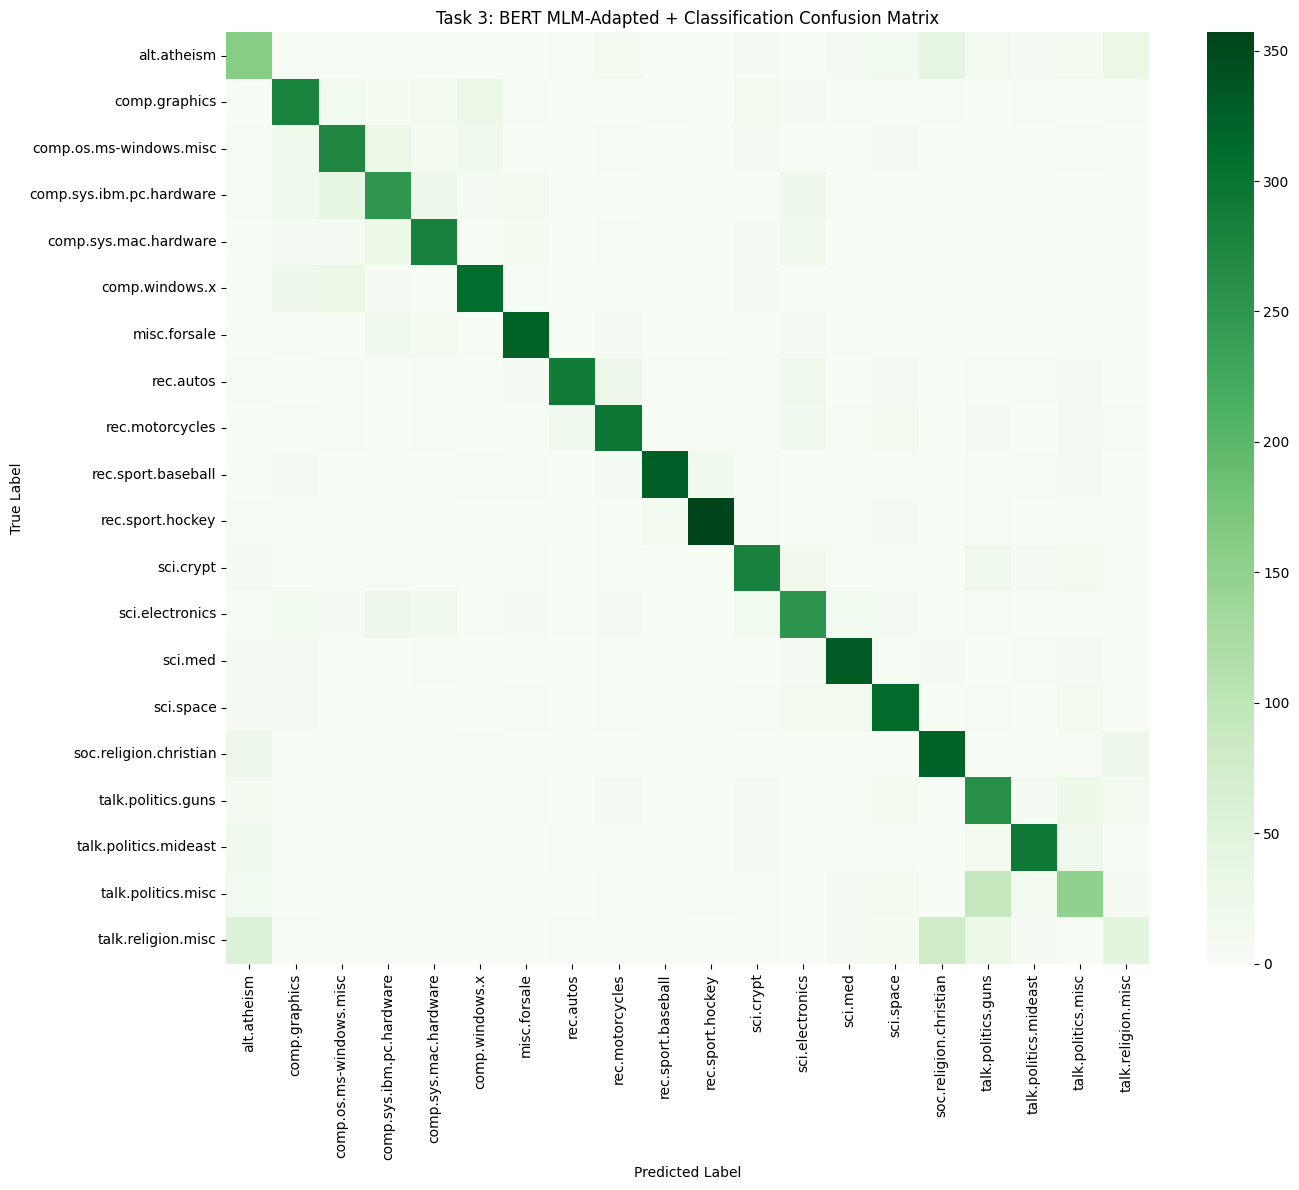

,Model,Test Accuracy (%),Test Precision,Test Recall,Test F1,MLM Eval Loss,MLM Train Samples
0,BERT MLM-adapted then fine-tuned,74.01,0.7381,0.7401,0.737,2.392,9912


In [ ]:
print(classification_report(task3_y_true, task3_y_pred, target_names=label_names, zero_division=0))

cm = confusion_matrix(task3_y_true, task3_y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Greens", annot=False, xticklabels=label_names, yticklabels=label_names)
plt.title("Task 3: BERT MLM-Adapted + Classification Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task3_confusion_matrix.png", dpi=200)
plt.show()

task3_results_df = pd.DataFrame([{
    "Model": "BERT MLM-adapted then fine-tuned",
    "Test Accuracy (%)": round(task3_accuracy * 100, 2),
    "Test Precision": round(task3_precision, 4),
    "Test Recall": round(task3_recall, 4),
    "Test F1": round(task3_f1, 4),
    "MLM Eval Loss": round(mlm_eval_results["eval_loss"], 4),
    "MLM Train Samples": len(mlm_texts),
}])
task3_results_df.to_csv(OUTPUT_DIR / "task3_bert_mlm_results.csv", index=False)
task3_results_df

# Task 4: Llama-3 Zero-Shot and Few-Shot Classification

This section treats Llama-3 as a prompting-based classifier. It does not train the model. Start with a subset of the test set, then increase it once the prompt and parsing work well.

In [ ]:
llama_eval_df = pd.DataFrame({"text": test_texts, "label": test_labels})

samples_per_class = 100  # 100 x 20 classes = 2000 samples

llama_eval_df = (
    llama_eval_df
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=SEED))
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

few_shot_source_df = pd.DataFrame({"text": train_texts, "label": train_labels})

print("Llama eval samples:", len(llama_eval_df))
print(llama_eval_df["label"].value_counts().sort_index())

Llama eval samples: 2000
label
0     100
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
Name: count, dtype: int64


In [ ]:
def shorten_text(text, max_chars=1200):
    text = " ".join(text.split())
    return text[:max_chars]

label_list_text = "\n".join([f"{i}: {label}" for i, label in id2label.items()])

def make_zero_shot_prompt(text):
    return (
        "You are classifying a document from the 20 Newsgroups dataset.\n"
        "Choose exactly one category from this list:\n"
        f"{label_list_text}\n\n"
        f"Document:\n{shorten_text(text)}\n\n"
        "Return only the label number, with no explanation."
    )

def build_few_shot_examples(source_df, examples_per_class=1, max_chars=500):
    rows = []
    for label_id, label_name in id2label.items():
        class_rows = source_df[source_df["label"] == label_id].sample(
            n=examples_per_class,
            random_state=SEED
        )
        for _, row in class_rows.iterrows():
            rows.append(
                f"Document: {shorten_text(row['text'], max_chars=max_chars)}\n"
                f"Label: {label_id}"
            )
    return "\n\n".join(rows)

few_shot_examples = build_few_shot_examples(few_shot_source_df, examples_per_class=1)

def make_few_shot_prompt(text):
    return (
        "You are classifying documents from the 20 Newsgroups dataset.\n"
        "Choose exactly one category from this list:\n"
        f"{label_list_text}\n\n"
        f"Examples. Each example ends with the correct label number:\n{few_shot_examples}\n\n"
        f"Now classify this document:\nDocument: {shorten_text(text)}\n\n"
        "Return only the label number, with no explanation."
    )

print(make_zero_shot_prompt(llama_eval_df.loc[0, "text"])[:1500])


You are classifying a document from the 20 Newsgroups dataset.
Choose exactly one category from this list:
0: alt.atheism
1: comp.graphics
2: comp.os.ms-windows.misc
3: comp.sys.ibm.pc.hardware
4: comp.sys.mac.hardware
5: comp.windows.x
6: misc.forsale
7: rec.autos
8: rec.motorcycles
9: rec.sport.baseball
10: rec.sport.hockey
11: sci.crypt
12: sci.electronics
13: sci.med
14: sci.space
15: soc.religion.christian
16: talk.politics.guns
17: talk.politics.mideast
18: talk.politics.misc
19: talk.religion.misc

Document:
And this results in a fire that starts in one room and torches the entire place before anyone in the adjacent rooms can escape? I don't think so. So much for the smolder theory.

Return only the label number, with no explanation.


In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

llama_tokenizer = AutoTokenizer.from_pretrained(LLAMA_MODEL_NAME, token=hf_token)
llama_model = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL_NAME,
    token=hf_token,
    device_map="auto",
    quantization_config=quantization_config,
)

llama_pipe = pipeline("text-generation", model=llama_model, tokenizer=llama_tokenizer)
print("Loaded", LLAMA_MODEL_NAME)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded meta-llama/Meta-Llama-3-8B-Instruct


In [ ]:
def generate_llama_answer(prompt, max_new_tokens=24):
    messages = [
        {"role": "system", "content": "You are a precise text classification assistant."},
        {"role": "user", "content": prompt},
    ]
    formatted_prompt = llama_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    output = llama_pipe(
        formatted_prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        return_full_text=False,
        pad_token_id=llama_tokenizer.eos_token_id,
    )[0]["generated_text"]
    return output.strip()

def parse_llama_label(answer):
    cleaned = answer.strip().split()[0].strip(" .,:;")
    if cleaned.isdigit():
        label_id = int(cleaned)
        if label_id in id2label:
            return label_id
    return -1

answer = generate_llama_answer(
    make_zero_shot_prompt(llama_eval_df.loc[0, "text"]),
    max_new_tokens=4
)
print("Raw answer:", answer)
print("Parsed label:", parse_llama_label(answer), id2label.get(parse_llama_label(answer), "unparsed"))


Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Raw answer: 17
Parsed label: 17 talk.politics.mideast


In [ ]:
def run_llama_classification_experiment(prompt_type="zero_shot"):
    assert prompt_type in {"zero_shot", "few_shot"}
    wandb.init(
        project=WANDB_PROJECT,
        name=f"task4_llama3_{prompt_type}",
        config={
            "experiment_type": f"Llama-3 {prompt_type} classification",
            "model": LLAMA_MODEL_NAME,
            "dataset": "20 Newsgroups",
            "num_eval_samples": len(llama_eval_df),
            "max_input_chars": 1200,
        },
    )

    records = []
    for i, row in llama_eval_df.iterrows():
        prompt = make_zero_shot_prompt(row["text"]) if prompt_type == "zero_shot" else make_few_shot_prompt(row["text"])
        raw_answer = generate_llama_answer(prompt, max_new_tokens=4)
        pred_label = parse_llama_label(raw_answer)
        records.append({
            "index": i,
            "prompt_type": prompt_type,
            "true_label_id": int(row["label"]),
            "true_label": id2label[int(row["label"])],
            "pred_label_id": int(pred_label),
            "pred_label": id2label.get(int(pred_label), "UNPARSED"),
            "raw_answer": raw_answer,
            "text_preview": shorten_text(row["text"], max_chars=250),
        })
        if (i + 1) % 10 == 0:
            print(f"{prompt_type}: processed {i + 1}/{len(llama_eval_df)}")

    results_df = pd.DataFrame(records)
    y_true = results_df["true_label_id"].to_numpy()
    y_pred = results_df["pred_label_id"].to_numpy()
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    unparsed_rate = (results_df["pred_label_id"] == -1).mean()
    metrics = {"test_accuracy": accuracy, "test_precision": precision, "test_recall": recall, "test_f1": f1, "unparsed_rate": unparsed_rate}

    wandb.log(metrics)
    wandb.log({"predictions": wandb.Table(dataframe=results_df)})
    wandb.finish()

    output_path = OUTPUT_DIR / f"task4_llama3_{prompt_type}_predictions.csv"
    results_df.to_csv(output_path, index=False)
    print(metrics)
    return results_df, metrics

In [ ]:
llama_zero_shot_df, llama_zero_shot_metrics = run_llama_classification_experiment("zero_shot")
llama_zero_shot_df.head()

Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

zero_shot: processed 10/2000


Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

zero_shot: processed 20/2000


Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

zero_shot: processed 2000/2000


test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
unparsed_rate,▁
test_accuracy,0.342
test_f1,0.31474
test_precision,0.51011
test_recall,0.342
unparsed_rate,0


{'test_accuracy': 0.342, 'test_precision': 0.5101100174569079, 'test_recall': 0.342, 'test_f1': 0.31473891786856967, 'unparsed_rate': np.float64(0.0)}


,index,prompt_type,true_label_id,true_label,pred_label_id,pred_label,raw_answer,text_preview
0,0,zero_shot,18,talk.politics.misc,17,talk.politics.mideast,17,And this results in a fire that starts in one ...
1,1,zero_shot,3,comp.sys.ibm.pc.hardware,4,comp.sys.mac.hardware,4,Can any body tell me where the most significan...
2,2,zero_shot,13,sci.med,13,sci.med,13,Point 1: I'm beginning to see that *part* of t...
3,3,zero_shot,9,rec.sport.baseball,14,sci.space,14,Right. Most definitely. This may be the root o...
4,4,zero_shot,12,sci.electronics,16,talk.politics.guns,16,ISBN 0-13-747270-6


In [ ]:
llama_few_shot_df, llama_few_shot_metrics = run_llama_classification_experiment("few_shot")
llama_few_shot_df.head()

Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

few_shot: processed 10/2000


Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

few_shot: processed 20/2000


Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

few_shot: processed 2000/2000


test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
unparsed_rate,▁
test_accuracy,0.3175
test_f1,0.28139
test_precision,0.42117
test_recall,0.3175
unparsed_rate,0


{'test_accuracy': 0.3175, 'test_precision': 0.4211703699339426, 'test_recall': 0.3175, 'test_f1': 0.2813878545729885, 'unparsed_rate': np.float64(0.0)}


,index,prompt_type,true_label_id,true_label,pred_label_id,pred_label,raw_answer,text_preview
0,0,few_shot,18,talk.politics.misc,9,rec.sport.baseball,9,And this results in a fire that starts in one ...
1,1,few_shot,3,comp.sys.ibm.pc.hardware,5,comp.windows.x,5,Can any body tell me where the most significan...
2,2,few_shot,13,sci.med,13,sci.med,13,Point 1: I'm beginning to see that *part* of t...
3,3,few_shot,9,rec.sport.baseball,16,talk.politics.guns,16,Right. Most definitely. This may be the root o...
4,4,few_shot,12,sci.electronics,12,sci.electronics,12,ISBN 0-13-747270-6


In [ ]:
def plot_llama_confusion(results_df, title, filename):
    valid_df = results_df[results_df["pred_label_id"] != -1]
    cm = confusion_matrix(valid_df["true_label_id"], valid_df["pred_label_id"], labels=list(id2label.keys()))
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, cmap="Purples", annot=False, xticklabels=label_names, yticklabels=label_names)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()

plot_llama_confusion(llama_zero_shot_df, "Task 4: Llama-3 Zero-Shot Confusion Matrix", "task4_llama3_zero_shot_confusion.png")
plot_llama_confusion(llama_few_shot_df, "Task 4: Llama-3 Few-Shot Confusion Matrix", "task4_llama3_few_shot_confusion.png")

# Final Comparison Table

In [ ]:
previous_results_rows = [
    {
        "Model": "Word2Vec (1 epoch) + Simple NN",
        "Evaluation Samples": 7532,
        "Test Accuracy (%)": 26.43,
        "Test Precision": 0.2424,
        "Test Recall": 0.2643,
        "Test F1": 0.2349,
        "Notes": "Task 1 baseline Word2Vec",
    },
    {
        "Model": "Word2Vec (3 epochs) + Simple NN",
        "Evaluation Samples": 7532,
        "Test Accuracy (%)": 45.30,
        "Test Precision": 0.4452,
        "Test Recall": 0.4530,
        "Test F1": 0.4384,
        "Notes": "Task 1 Word2Vec",
    },
    {
        "Model": "Word2Vec (5 epochs) + Simple NN",
        "Evaluation Samples": 7532,
        "Test Accuracy (%)": 53.05,
        "Test Precision": 0.5283,
        "Test Recall": 0.5305,
        "Test F1": 0.5182,
        "Notes": "Task 1 Word2Vec",
    },
    {
        "Model": "Word2Vec (10 epochs) + Simple NN",
        "Evaluation Samples": 7532,
        "Test Accuracy (%)": 59.76,
        "Test Precision": 0.6027,
        "Test Recall": 0.5976,
        "Test F1": 0.5905,
        "Notes": "Task 1 Word2Vec",
    },
    {
        "Model": "Word2Vec (20 epochs) + Simple NN",
        "Evaluation Samples": 7532,
        "Test Accuracy (%)": 62.61,
        "Test Precision": 0.6343,
        "Test Recall": 0.6261,
        "Test F1": 0.6176,
        "Notes": "Task 1 Word2Vec",
    },
    {
        "Model": "TF-IDF + Simple NN",
        "Evaluation Samples": 7532,
        "Test Accuracy (%)": 64.23,
        "Test Precision": 0.6555,
        "Test Recall": 0.6423,
        "Test F1": 0.6458,
        "Notes": "Task 1 TF-IDF",
    },
    {
        "Model": "TF-IDF (1,2)-grams + Simple NN",
        "Evaluation Samples": 7532,
        "Test Accuracy (%)": 66.95,
        "Test Precision": 0.6811,
        "Test Recall": 0.6695,
        "Test F1": 0.6720,
        "Notes": "Task 1 extra experiment",
    },
    {
        "Model": "TF-IDF (1,2)-grams + no empty docs",
        "Evaluation Samples": 7317,
        "Test Accuracy (%)": 68.75,
        "Test Precision": 0.6897,
        "Test Recall": 0.6875,
        "Test F1": 0.6870,
        "Notes": "Best Task 1 result",
    },
    {
        "Model": "BERT base fine-tuned",
        "Evaluation Samples": 7317,
        "Test Accuracy (%)": 73.28,
        "Test Precision": 0.7299,
        "Test Recall": 0.7328,
        "Test F1": 0.7289,
        "Notes": "Task 2",
    },
]

comparison_rows = previous_results_rows + [
    {
        "Model": "BERT MLM-adapted then fine-tuned",
        "Evaluation Samples": len(test_labels_for_bert),
        "Test Accuracy (%)": round(task3_accuracy * 100, 2),
        "Test Precision": round(task3_precision, 4),
        "Test Recall": round(task3_recall, 4),
        "Test F1": round(task3_f1, 4),
        "Notes": f"MLM samples: {len(mlm_texts)}",
    },
    {
        "Model": "Llama-3 zero-shot",
        "Evaluation Samples": len(llama_eval_df),
        "Test Accuracy (%)": round(llama_zero_shot_metrics["test_accuracy"] * 100, 2),
        "Test Precision": round(llama_zero_shot_metrics["test_precision"], 4),
        "Test Recall": round(llama_zero_shot_metrics["test_recall"], 4),
        "Test F1": round(llama_zero_shot_metrics["test_f1"], 4),
        "Notes": f"Unparsed rate: {llama_zero_shot_metrics['unparsed_rate']:.2%}",
    },
    {
        "Model": "Llama-3 few-shot",
        "Evaluation Samples": len(llama_eval_df),
        "Test Accuracy (%)": round(llama_few_shot_metrics["test_accuracy"] * 100, 2),
        "Test Precision": round(llama_few_shot_metrics["test_precision"], 4),
        "Test Recall": round(llama_few_shot_metrics["test_recall"], 4),
        "Test F1": round(llama_few_shot_metrics["test_f1"], 4),
        "Notes": f"Unparsed rate: {llama_few_shot_metrics['unparsed_rate']:.2%}",
    },
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUTPUT_DIR / "tasks_3_4_comparison_results.csv", index=False)
comparison_df

,Model,Evaluation Samples,Test Accuracy (%),Test Precision,Test Recall,Test F1,Notes
0,Word2Vec (1 epoch) + Simple NN,7532,26.43,0.2424,0.2643,0.2349,Task 1 baseline Word2Vec
1,Word2Vec (3 epochs) + Simple NN,7532,45.30,0.4452,0.4530,0.4384,Task 1 Word2Vec
2,Word2Vec (5 epochs) + Simple NN,7532,53.05,0.5283,0.5305,0.5182,Task 1 Word2Vec
3,Word2Vec (10 epochs) + Simple NN,7532,59.76,0.6027,0.5976,0.5905,Task 1 Word2Vec
4,Word2Vec (20 epochs) + Simple NN,7532,62.61,0.6343,0.6261,0.6176,Task 1 Word2Vec
5,TF-IDF + Simple NN,7532,64.23,0.6555,0.6423,0.6458,Task 1 TF-IDF
6,"TF-IDF (1,2)-grams + Simple NN",7532,66.95,0.6811,0.6695,0.6720,Task 1 extra experiment
7,"TF-IDF (1,2)-grams + no empty docs",7317,68.75,0.6897,0.6875,0.6870,Best Task 1 result
8,BERT base fine-tuned,7317,73.28,0.7299,0.7328,0.7289,Task 2
9,BERT MLM-adapted then fine-tuned,7317,74.01,0.7381,0.7401,0.7370,MLM samples: 9912


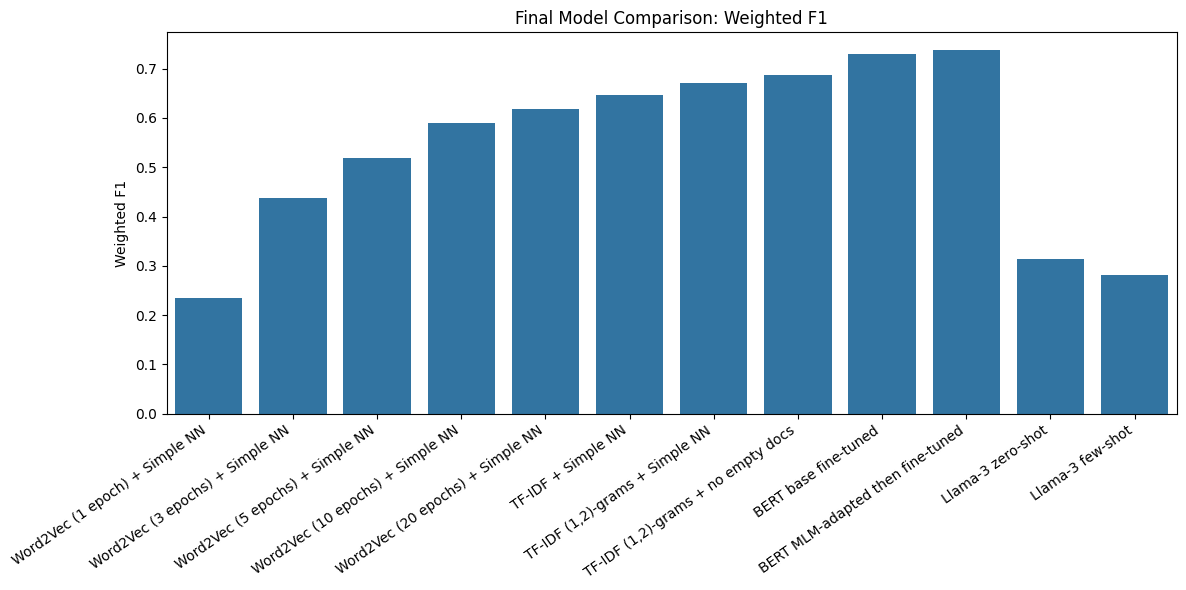

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x="Model", y="Test F1")
plt.title("Final Model Comparison: Weighted F1")
plt.ylabel("Weighted F1")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_f1_comparison.png", dpi=200)
plt.show()

# ============================================================
# Extra Analysis: Llama-3 Zero-Shot with Full Document Context
# ============================================================

This experiment uses the original 20 Newsgroups test documents,without removing headers, footers, or quotes.
It is NOT directly comparable to the main cleaned-data results, but it helps test whether Llama benefits from extra document context.

In [ ]:
full_test_data = fetch_20newsgroups(subset="test")

full_test_df = pd.DataFrame({
    "text": full_test_data.data,
    "label": full_test_data.target
})

full_test_df = full_test_df[full_test_df["text"].str.strip() != ""].reset_index(drop=True)

samples_per_class = 100  # 100 x 20 classes = 2000 samples

llama_full_context_eval_df = (
    full_test_df
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=SEED))
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print("Full-context Llama eval samples:", len(llama_full_context_eval_df))
print(llama_full_context_eval_df["label"].value_counts().sort_index())

Full-context Llama eval samples: 2000
label
0     100
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
Name: count, dtype: int64


In [ ]:
def shorten_full_context_text(text, max_chars=2000):
    text = " ".join(text.split())
    return text[:max_chars]

full_context_label_list_text = "\n".join([
    f"{i}: {label}" for i, label in id2label.items()
])

def make_full_context_zero_shot_prompt(text):
    return (
        "You are classifying a document from the 20 Newsgroups dataset.\n"
        "The document may include headers, quoted text, email metadata, or thread context.\n"
        "Use all available information to choose exactly one category from this list:\n"
        f"{full_context_label_list_text}\n\n"
        f"Document:\n{shorten_full_context_text(text)}\n\n"
        "Return only the label number, with no explanation."
    )

In [ ]:
def run_llama_full_context_zero_shot_experiment():
    wandb.init(
        project=WANDB_PROJECT,
        name="task4_llama3_zero_shot_full_context",
        config={
            "experiment_type": "Llama-3 zero-shot classification with full document context",
            "model": LLAMA_MODEL_NAME,
            "dataset": "20 Newsgroups",
            "preprocessing": "headers_footers_quotes_included",
            "num_eval_samples": len(llama_full_context_eval_df),
            "samples_per_class": samples_per_class,
            "max_input_chars": 2000,
        },
    )

    records = []

    for i, row in llama_full_context_eval_df.iterrows():
        prompt = make_full_context_zero_shot_prompt(row["text"])
        raw_answer = generate_llama_answer(prompt, max_new_tokens=4)
        pred_label = parse_llama_label(raw_answer)

        records.append({
            "index": i,
            "prompt_type": "zero_shot_full_context",
            "true_label_id": int(row["label"]),
            "true_label": id2label[int(row["label"])],
            "pred_label_id": int(pred_label),
            "pred_label": id2label.get(int(pred_label), "UNPARSED"),
            "raw_answer": raw_answer,
            "text_preview": shorten_full_context_text(row["text"], max_chars=350),
        })

        if (i + 1) % 25 == 0:
            print(f"full-context zero-shot: processed {i + 1}/{len(llama_full_context_eval_df)}")

    results_df = pd.DataFrame(records)

    y_true_full_context = results_df["true_label_id"].to_numpy()
    y_pred_full_context = results_df["pred_label_id"].to_numpy()

    accuracy = accuracy_score(y_true_full_context, y_pred_full_context)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_full_context,
        y_pred_full_context,
        average="weighted",
        zero_division=0
    )
    unparsed_rate = (results_df["pred_label_id"] == -1).mean()

    metrics = {
        "test_accuracy": accuracy,
        "test_precision": precision,
        "test_recall": recall,
        "test_f1": f1,
        "unparsed_rate": unparsed_rate,
    }

    wandb.log(metrics)
    wandb.log({"predictions": wandb.Table(dataframe=results_df)})
    wandb.finish()

    output_path = OUTPUT_DIR / "task4_llama3_zero_shot_full_context_predictions.csv"
    results_df.to_csv(output_path, index=False)

    print(metrics)
    return results_df, metrics

In [ ]:
llama_full_context_df, llama_full_context_metrics = run_llama_full_context_zero_shot_experiment()

llama_full_context_df.head()

Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

full-context zero-shot: processed 25/2000


Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

full-context zero-shot: processed 50/2000


Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

full-context zero-shot: processed 2000/2000


test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
unparsed_rate,▁
test_accuracy,0.3775
test_f1,0.34335
test_precision,0.49507
test_recall,0.3775
unparsed_rate,0


{'test_accuracy': 0.3775, 'test_precision': 0.4950656573263833, 'test_recall': 0.3775, 'test_f1': 0.3433501581203184, 'unparsed_rate': np.float64(0.0)}


,index,prompt_type,true_label_id,true_label,pred_label_id,pred_label,raw_answer,text_preview
0,0,zero_shot_full_context,18,talk.politics.misc,16,talk.politics.guns,16,From: V2110A@VM.TEMPLE.EDU (Richard Hoenes) Su...
1,1,zero_shot_full_context,3,comp.sys.ibm.pc.hardware,3,comp.sys.ibm.pc.hardware,3,From: Randy Ellingson Subject: SCSI or IDE: Th...
2,2,zero_shot_full_context,13,sci.med,14,sci.space,14,From: mcovingt@aisun4.ai.uga.edu (Michael Covi...
3,3,zero_shot_full_context,9,rec.sport.baseball,9,rec.sport.baseball,9,From: sac@asdi.saic.com (Steve A. Conroy x6172...
4,4,zero_shot_full_context,12,sci.electronics,14,sci.space,14,From: lihan@ccwf.cc.utexas.edu (Bruce G. Bostw...


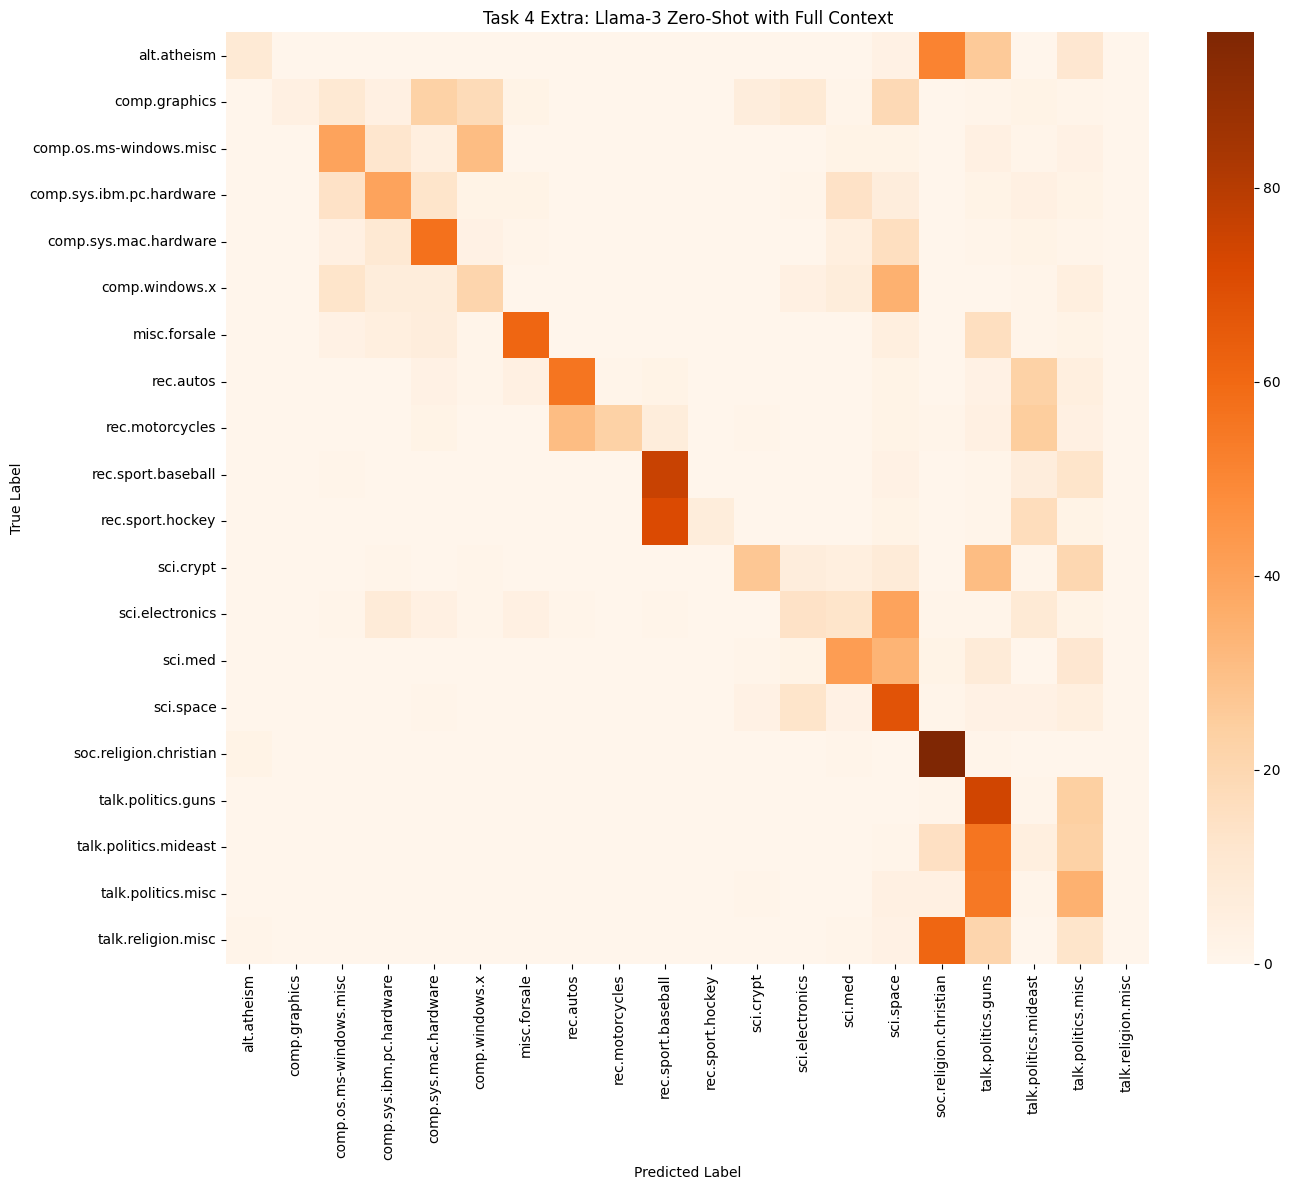

In [ ]:
valid_full_context_df = llama_full_context_df[
    llama_full_context_df["pred_label_id"] != -1
]

cm = confusion_matrix(
    valid_full_context_df["true_label_id"],
    valid_full_context_df["pred_label_id"],
    labels=list(id2label.keys())
)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Oranges",
    annot=False,
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Task 4 Extra: Llama-3 Zero-Shot with Full Context")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task4_llama3_zero_shot_full_context_confusion.png", dpi=200)
plt.show()

In [ ]:
full_context_row = {
    "Model": "Llama-3 zero-shot, full context",
    "Evaluation Samples": len(llama_full_context_eval_df),
    "Test Accuracy (%)": round(llama_full_context_metrics["test_accuracy"] * 100, 2),
    "Test Precision": round(llama_full_context_metrics["test_precision"], 4),
    "Test Recall": round(llama_full_context_metrics["test_recall"], 4),
    "Test F1": round(llama_full_context_metrics["test_f1"], 4),
    "Notes": (
        f"Headers/footers/quotes included; "
        f"unparsed rate: {llama_full_context_metrics['unparsed_rate']:.2%}"
    ),
}

comparison_df = pd.concat(
    [comparison_df, pd.DataFrame([full_context_row])],
    ignore_index=True
)

comparison_df = comparison_df.drop_duplicates(
    subset=["Model"],
    keep="last"
).reset_index(drop=True)

comparison_df = comparison_df.sort_values(
    by="Test F1",
    ascending=False
).reset_index(drop=True)

comparison_df.to_csv(
    OUTPUT_DIR / "final_comparison_sorted_by_f1.csv",
    index=False
)

comparison_df

,Model,Evaluation Samples,Test Accuracy (%),Test Precision,Test Recall,Test F1,Notes
0,BERT MLM-adapted then fine-tuned,7317,74.01,0.7381,0.7401,0.7370,MLM samples: 9912
1,BERT base fine-tuned,7317,73.28,0.7299,0.7328,0.7289,Task 2
2,"TF-IDF (1,2)-grams + no empty docs",7317,68.75,0.6897,0.6875,0.6870,Best Task 1 result
3,"TF-IDF (1,2)-grams + Simple NN",7532,66.95,0.6811,0.6695,0.6720,Task 1 extra experiment
4,TF-IDF + Simple NN,7532,64.23,0.6555,0.6423,0.6458,Task 1 TF-IDF
5,Word2Vec (20 epochs) + Simple NN,7532,62.61,0.6343,0.6261,0.6176,Task 1 Word2Vec
6,Word2Vec (10 epochs) + Simple NN,7532,59.76,0.6027,0.5976,0.5905,Task 1 Word2Vec
7,Word2Vec (5 epochs) + Simple NN,7532,53.05,0.5283,0.5305,0.5182,Task 1 Word2Vec
8,Word2Vec (3 epochs) + Simple NN,7532,45.30,0.4452,0.4530,0.4384,Task 1 Word2Vec
9,"Llama-3 zero-shot, full context",2000,37.75,0.4951,0.3775,0.3434,Headers/footers/quotes included; unparsed rate...


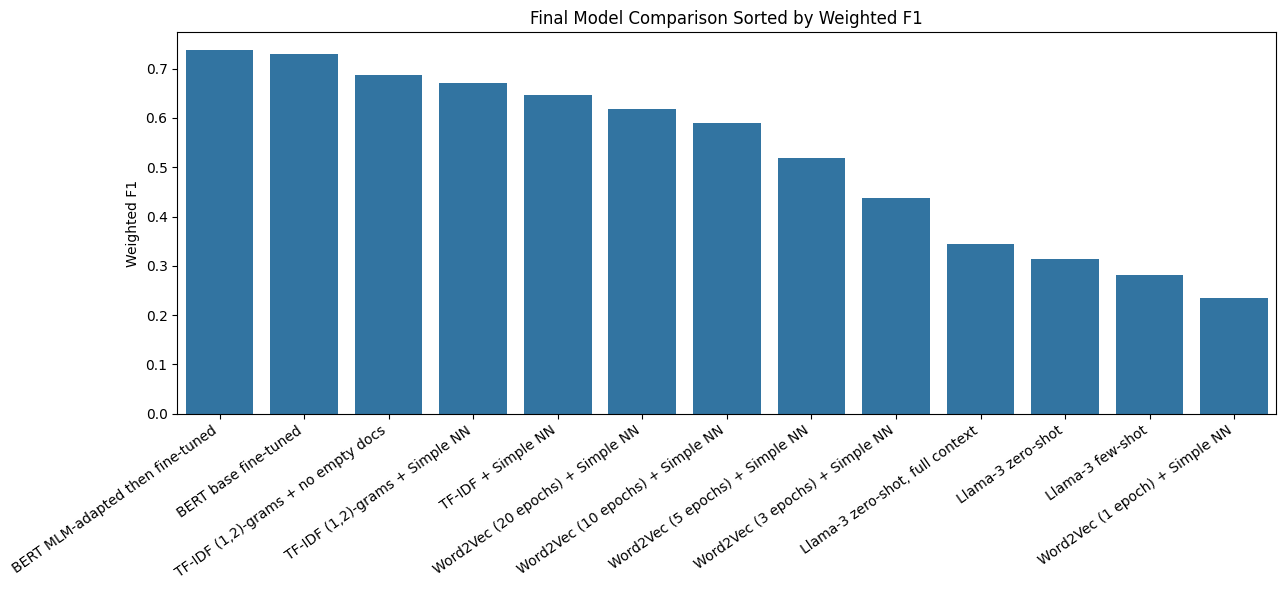

In [ ]:
plt.figure(figsize=(13, 6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Test F1",
    order=comparison_df["Model"]
)

plt.title("Final Model Comparison Sorted by Weighted F1")
plt.ylabel("Weighted F1")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_comparison_sorted_by_f1.png", dpi=200)
plt.show()

# Saving Output Files to Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os

drive_output_dir = "/content/drive/MyDrive/NALAPRO_Final_Project/outputs"
os.makedirs(drive_output_dir, exist_ok=True)

In [ ]:
import shutil

files_to_copy = [
    "task_3_4_outputs/task3_bert_mlm_results.csv",
    "task_3_4_outputs/task3_confusion_matrix.png",

    "task_3_4_outputs/task4_llama3_zero_shot_predictions.csv",
    "task_3_4_outputs/task4_llama3_zero_shot_confusion.png",

    "task_3_4_outputs/task4_llama3_few_shot_predictions.csv",
    "task_3_4_outputs/task4_llama3_few_shot_confusion.png",

    "task_3_4_outputs/task4_llama3_zero_shot_full_context_predictions.csv",
    "task_3_4_outputs/task4_llama3_zero_shot_full_context_confusion.png",

    "task_3_4_outputs/tasks_3_4_comparison_results.csv",
    "task_3_4_outputs/tasks_3_4_comparison_results_with_full_context.csv",

    "task_3_4_outputs/final_comparison_sorted_by_f1.csv",
    "task_3_4_outputs/final_comparison_sorted_by_f1.png",
]

for file in files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, drive_output_dir)
        print("Copied:", file)
    else:
        print("Missing:", file)

Copied: task_3_4_outputs/task3_bert_mlm_results.csv
Copied: task_3_4_outputs/task3_confusion_matrix.png
Copied: task_3_4_outputs/task4_llama3_zero_shot_predictions.csv
Copied: task_3_4_outputs/task4_llama3_zero_shot_confusion.png
Copied: task_3_4_outputs/task4_llama3_few_shot_predictions.csv
Copied: task_3_4_outputs/task4_llama3_few_shot_confusion.png
Copied: task_3_4_outputs/task4_llama3_zero_shot_full_context_predictions.csv
Copied: task_3_4_outputs/task4_llama3_zero_shot_full_context_confusion.png
Copied: task_3_4_outputs/tasks_3_4_comparison_results.csv
Copied: task_3_4_outputs/tasks_3_4_comparison_results_with_full_context.csv
Copied: task_3_4_outputs/final_comparison_sorted_by_f1.csv
Copied: task_3_4_outputs/final_comparison_sorted_by_f1.png
